In [2]:
import numpy as np
import numpy.linalg as LA

固有値を求めると次の通り

$\lambda = 0 ,\pm \sqrt{B^2_z + 2(B^2_x + B^2_y)} $

In [144]:


Bx=1
By=1
Bz=100
 
A = np.array([[Bz, 
               Bx-By*1j,0],
              [Bx+By*1j,0, Bx-By*1j],
              [0,Bx+By*1j,-Bz]])
eig, v = np.linalg.eig(A)


print(eig)

[ 1.00019998e+02+3.13924321e-18j -8.45672410e-18-3.13892935e-18j
 -1.00019998e+02-3.13861552e-22j]


In [145]:
print(v)

[[ 9.99900030e-01+0.0000000e+00j -9.99800060e-03+9.9980006e-03j
  -6.50001666e-21-9.9970010e-05j]
 [ 9.99800060e-03+9.9980006e-03j  9.99800060e-01+0.0000000e+00j
  -9.99800060e-03+9.9980006e-03j]
 [-2.21930942e-20+9.9970010e-05j  9.99800060e-03+9.9980006e-03j
   9.99900030e-01+0.0000000e+00j]]


行列を基本変形して得た固有値と、行列全体を固有方程式として解いた際の固有値に、わずかではあるが値のずれがみられる。

In [275]:
Bx=10e-4
By=10e-4
Bz=10e-4

H_tot = np.array([[Bz, Bx-By*1j, 0 , -Bz*1j,0,0],
              [Bx+By*1j,0, Bx-By*1j,0,-Bz*1j,0],
              [0,Bx+By*1j,-Bz,0,0,-Bz*1j],
              [Bz*1j,0,0,Bz,Bx-By*1j,0],
              [0,Bz*1j,0,Bx+By*1j,0, Bx-By*1j],
              [0,0,Bz*1j,0,Bx+By*1j,-Bz]])
eig, eig_v = np.linalg.eig(H_tot)
print(eig)

[ 0.00323607-1.78793955e-20j -0.00323607+1.66925736e-20j
  0.00123607+2.00405736e-19j  0.001     -5.44037415e-20j
 -0.001     +6.02294658e-20j -0.00123607-1.75673113e-21j]


In [276]:

tmp  = np.abs(eig_v)
pro_list = np.square(tmp)

print(pro_list)



[[0.2618034 0.0381966 0.2618034 0.2       0.2       0.0381966]
 [0.2       0.2       0.2       0.1       0.1       0.2      ]
 [0.0381966 0.2618034 0.0381966 0.2       0.2       0.2618034]
 [0.2618034 0.0381966 0.2618034 0.2       0.2       0.0381966]
 [0.2       0.2       0.2       0.1       0.1       0.2      ]
 [0.0381966 0.2618034 0.0381966 0.2       0.2       0.2618034]]


In [263]:
vector_dict = {"|A_2>": "0","|A_1>": "1" ,"|E_x>": "2","|E_y>": "3","|E_4>": "0","|E_5>": "0"}

In [277]:
v0 =[pro_list[i][0] for i in range(6)] # |A_2>
v1 =[pro_list[i][1] for i in range(6)] # |E_x>
v2 =[pro_list[i][2] for i in range(6)] # |A_1>
v3 =[pro_list[i][3] for i in range(6)] # |E_1>
v4 =[pro_list[i][4] for i in range(6)] # |E_y>
v5 =[pro_list[i][5] for i in range(6)] # |E_2>



In [278]:
v0

[np.float64(0.26180339887498927),
 np.float64(0.1999999999999998),
 np.float64(0.0381966011250105),
 np.float64(0.26180339887499016),
 np.float64(0.19999999999999998),
 np.float64(0.038196601125010526)]

scoreの比例関係にある式の導出では、6つの和のうち一つ,２つを見ればいいことがわかる。

Ex+1,Ex0のscore を計算.
値に大きく影響するのは、$|A_2>,|E_x>,|E_y>$

In [279]:
score =   v4[0] * v4[1]

score

np.float64(0.02000000000000015)

In [280]:
eig_v_E_y =[eig_v[i][4] for i in range(6)] # |E_y>

In [281]:
a2 = eig_v_E_y[2]
a4 = eig_v_E_y[4]
a5 = eig_v_E_y[5]
B_perp = np.sqrt(Bx ** 2 + By ** 2)



In [282]:
tmp = np.abs(-(Bx-1j*By)/Bz * a2 + 1j * a4) * np.abs(a2 + 1j * a5)

In [288]:
tmp

np.float64(0.28284271247461806)

In [ ]:
tmp_approx = np.abs( 1j * a4) * np.abs(a2 + 1j * a5)

In [284]:
value = Bz ** 2 / (B_perp ** 2) * tmp  

expected = value ** 2

In [285]:
expected 

np.float64(0.019999999999999865)

In [286]:
value_approx  = Bz ** 2 / (B_perp ** 2) * tmp_approx

expected_approx = value_approx ** 2

In [287]:
expected

np.float64(0.019999999999999865)

$B_z$ に対する余剰項の変化について

In [328]:
import matplotlib.pyplot as plt

In [343]:
def Hamiltonian(Bx,By,Bz):
    H_tot = np.array([[Bz, Bx-By*1j, 0 , -Bz*1j*0.05,0,0],
              [Bx+By*1j,0, Bx-By*1j,0,-Bz*1j*0.05,0],
              [0,Bx+By*1j,-Bz,0,0,-Bz*1j*0.05],
              [Bz*1j*0.05,0,0,Bz,Bx-By*1j,0],
              [0,Bz*1j*0.05,0,Bx+By*1j,0, Bx-By*1j],
              [0,0,Bz*1j*0.05,0,Bx+By*1j,-Bz]])
    
    eig, eig_v = np.linalg.eig(H_tot)

    return eig_v


In [344]:
def computation_for_tmp(Bx,By,Bz_list):
    
    tmp_list = []
    B_perp = np.sqrt(Bx ** 2 + By ** 2)

    for Bz in Bz_list:
        eig_v = Hamiltonian(Bx,By,Bz)

        eig_v_E_y =[eig_v[i][4] for i in range(6)] # |E_y>

        a2 = eig_v_E_y[2]
        a4 = eig_v_E_y[4]
        a5 = eig_v_E_y[5]
       

        tmp_list.append(np.abs(-(Bx-1j*By)/Bz * a2 + 1j * a4) * np.abs(a2 + 1j * a5))

    return tmp_list

In [345]:
def computation_for_tmp_approx(Bx,By,Bz_list):
    
    tmp_list = []
    B_perp = np.sqrt(Bx ** 2 + By ** 2)

    for Bz in Bz_list:
        eig_v = Hamiltonian(Bx,By,Bz)

        eig_v_E_y =[eig_v[i][4] for i in range(6)] # |E_y>

        a2 = eig_v_E_y[2]
        a4 = eig_v_E_y[4]
        a5 = eig_v_E_y[5]
       

        tmp_list.append(np.abs(1j * a4) * np.abs(a2 + 1j * a5))

    return tmp_list

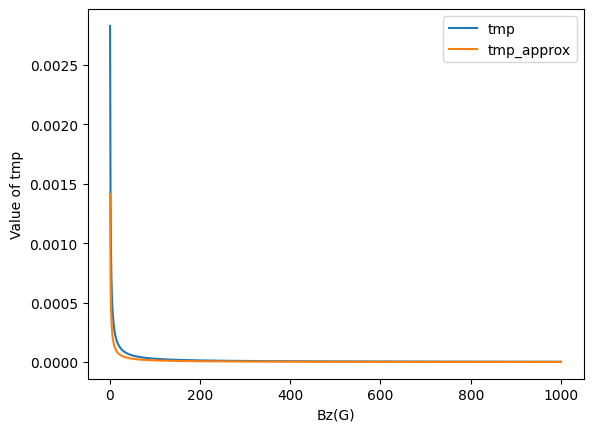

In [351]:
Bz_list = np.linspace(1,10e2, 1000)
result = computation_for_tmp(Bx,By,Bz_list)
result_approx = computation_for_tmp_approx(Bx,By,Bz_list)

fig = plt.figure()
plt.xlabel('Bz(G)')
plt.ylabel('Value of tmp')
plt.plot(Bz_list,result,label = 'tmp')
plt.plot(Bz_list,result_approx,label = 'tmp_approx')


plt.legend()


In [350]:
print(result)

[np.float64(5.476520316484916e-14), np.float64(0.002825309683271302), np.float64(0.0014127280431721692), np.float64(0.0009418347025395141), np.float64(0.0007063819930045733), np.float64(0.0005651084487716407), np.float64(0.0004709252898192726), np.float64(0.00040365121593576486), np.float64(0.00035319544822497547), np.float64(0.0003139519477047), np.float64(0.0002825570682232389), np.float64(0.00025687029641610555), np.float64(0.0002354646173589074), np.float64(0.00021735209423023958), np.float64(0.00020182705583467498), np.float64(0.00018837200869896127), np.float64(0.0001765988319010977), np.float64(0.00016621072654894446), np.float64(0.00015697684869047857), np.float64(0.0001487149528433702), np.float64(0.00014127924243781566), np.float64(0.00013455169154654584), np.float64(0.00012843573340402868), np.float64(0.00012285159538999018), np.float64(0.00011773280026795893), np.float64(0.00011302350711395073), np.float64(0.0001086764658833573), np.float64(0.00010465142651217906), np.float

In [353]:
10e2 * result[-1]

np.float64(0.002828427124790697)

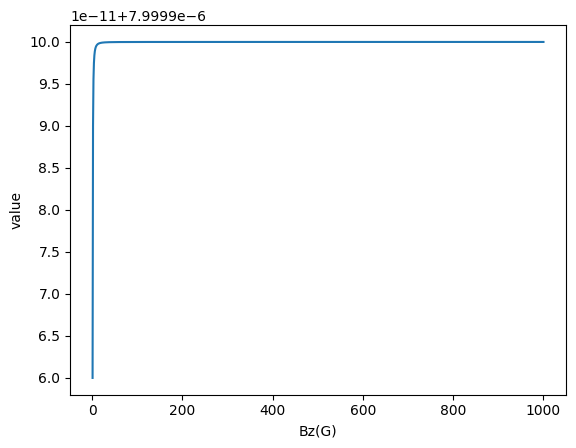

In [ ]:
fig = plt.figure()
plt.xlabel('Bz(G)')
plt.ylabel('value')

#Value = [(Bz**2) * (tmp**2) for Bz,tmp in zip(Bz_list,result)]

for Bz in Bz_list:
    for tmp in result

#plt.plot(Bz_list,Value,label = 'tmp*Bz')

$[a_1,a_2 
a_3,a_4
a_5,a_6]$